# Lab 3: Exploratory Data Analysis (EDA)


In [ ]:
# Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Make plots look cleaner
sns.set()

In [5]:
# Load Dataset

df = pd.read_csv("shopping_behavior_updated (1).csv")

# Display first 5 rows
df.head()

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1,Yes,Yes,23,Credit Card,Weekly
3,4,21,Male,Sandals,Footwear,90,Rhode Island,M,Maroon,Spring,3.5,Yes,Yes,49,PayPal,Weekly
4,5,45,Male,Blouse,Clothing,49,Oregon,M,Turquoise,Spring,2.7,Yes,Yes,31,PayPal,Annually


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

###Check the missing Value

In [6]:
print(df.isna())

      Customer ID    Age  Gender  Item Purchased  Category  \
0           False  False   False           False     False   
1           False  False   False           False     False   
2           False  False   False           False     False   
3           False  False   False           False     False   
4           False  False   False           False     False   
...           ...    ...     ...             ...       ...   
3895        False  False   False           False     False   
3896        False  False   False           False     False   
3897        False  False   False           False     False   
3898        False  False   False           False     False   
3899        False  False   False           False     False   

      Purchase Amount (USD)  Location   Size  Color  Season  Review Rating  \
0                     False     False  False  False   False          False   
1                     False     False  False  False   False          False   
2                    

In [7]:
print(df.isna().sum())

Customer ID               0
Age                       0
Gender                    0
Item Purchased            0
Category                  0
Purchase Amount (USD)     0
Location                  0
Size                      0
Color                     0
Season                    0
Review Rating             0
Subscription Status       0
Discount Applied          0
Previous Purchases        0
Payment Method            0
Frequency of Purchases    0
dtype: int64


### Check duplicate rows

In [8]:
df.duplicated()[df.duplicated()==True]

,0


### No. of rows and columns

In [9]:
print("Shape (rows, columns): ", df.shape,"\n")

print("number of rows: ", df.shape[0])
print("number of columns: ", df.shape[1])

Shape (rows, columns):  (3900, 16) 

number of rows:  3900
number of columns:  16


###Data type of colums

In [10]:
df.dtypes

,0
Customer ID,int64
Age,int64
Gender,object
Item Purchased,object
Category,object
Purchase Amount (USD),int64
Location,object
Size,object
Color,object
Season,object


### Descriptive summary Statistics

In [11]:
df.describe(include='all')

,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Discount Applied,Previous Purchases,Payment Method,Frequency of Purchases
count,3900.000000,3900.000000,3900,3900,3900,3900.000000,3900,3900,3900,3900,3900.000000,3900,3900,3900.000000,3900,3900
unique,NaN,NaN,2,25,4,NaN,50,4,25,4,NaN,2,2,NaN,6,7
top,NaN,NaN,Male,Blouse,Clothing,NaN,Montana,M,Olive,Spring,NaN,No,No,NaN,PayPal,Every 3 Months
freq,NaN,NaN,2652,171,1737,NaN,96,1755,177,999,NaN,2847,2223,NaN,677,584
mean,1950.500000,44.068462,NaN,NaN,NaN,59.764359,NaN,NaN,NaN,NaN,3.749949,NaN,NaN,25.351538,NaN,NaN
std,1125.977353,15.207589,NaN,NaN,NaN,23.685392,NaN,NaN,NaN,NaN,0.716223,NaN,NaN,14.447125,NaN,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20.000000,NaN,NaN,NaN,NaN,2.500000,NaN,NaN,1.000000,NaN,NaN
25%,975.750000,31.000000,NaN,NaN,NaN,39.000000,NaN,NaN,NaN,NaN,3.100000,NaN,NaN,13.000000,NaN,NaN
50%,1950.500000,44.000000,NaN,NaN,NaN,60.000000,NaN,NaN,NaN,NaN,3.700000,NaN,NaN,25.000000,NaN,NaN
75%,2925.250000,57.000000,NaN,NaN,NaN,81.000000,NaN,NaN,NaN,NaN,4.400000,NaN,NaN,38.000000,NaN,NaN


### Univariate Analysis

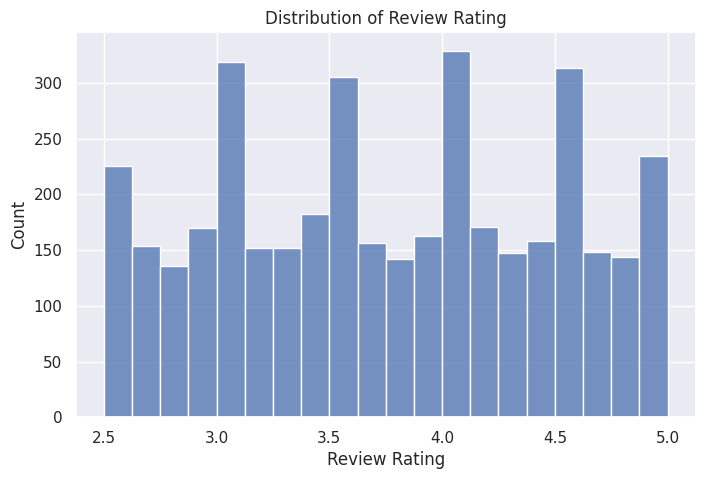

In [14]:
plt.figure(figsize=(8,5))
sns.histplot(df['Review Rating'], bins=20)
plt.title("Distribution of Review Rating")
plt.show()

- Shows how shipment sizes are distributed
- Right skew = many small shipments, few large ones

### Distribution of Revenue

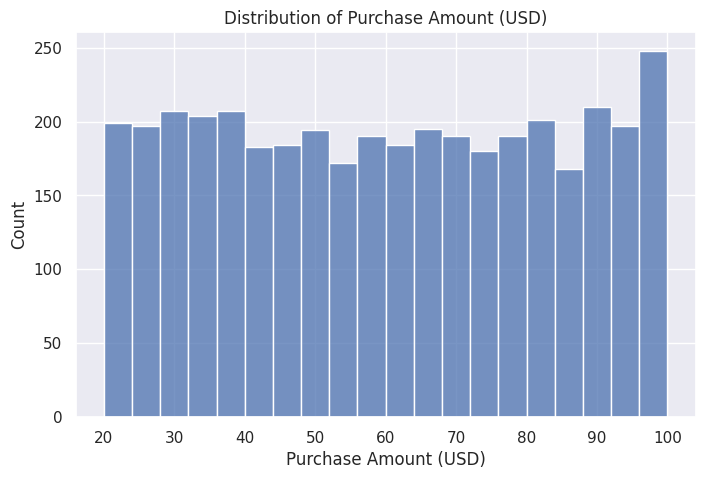

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df['Purchase Amount (USD)'], bins=20)
plt.title("Distribution of Purchase Amount (USD)")
plt.show()

## Bivariate Analysis

### Revenue by Country

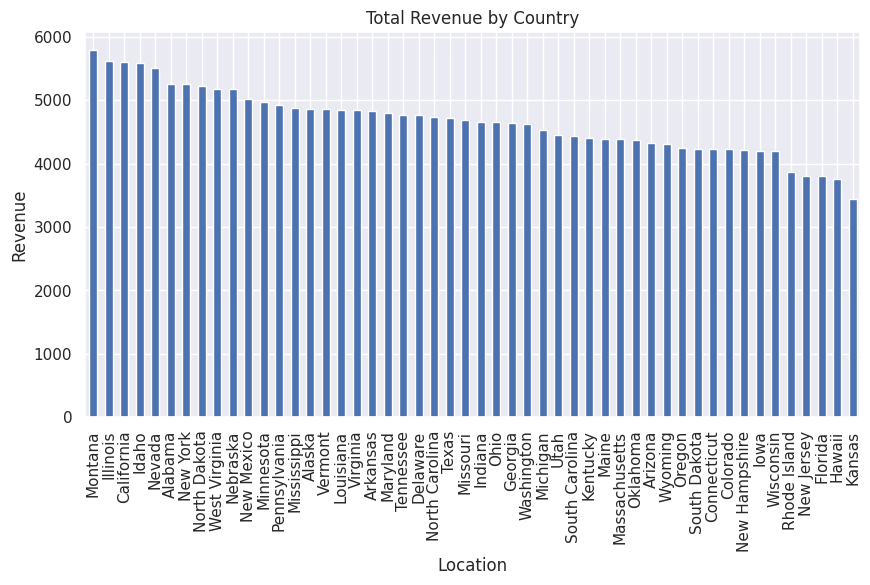

In [17]:
country_revenue = df.groupby('Location')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
country_revenue.plot(kind='bar')
plt.title("Total Revenue by Country")
plt.ylabel("Revenue")
plt.show()

### Revenue by Product

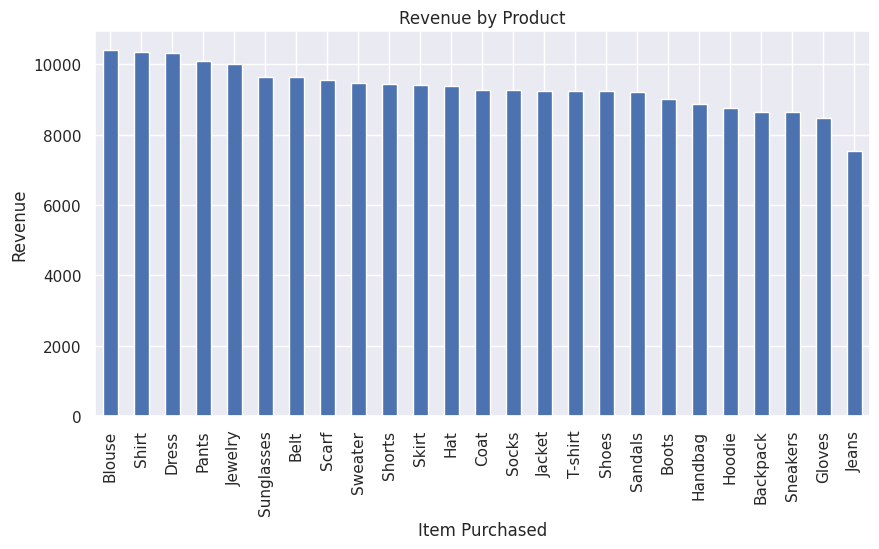

,Purchase Amount (USD)
Item Purchased,
Blouse,10410
Shirt,10332
Dress,10320
Pants,10090
Jewelry,10010
Sunglasses,9649
Belt,9635
Scarf,9561
Sweater,9462


In [19]:
product_revenue = df.groupby('Item Purchased')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,5))
product_revenue.plot(kind='bar')
plt.title("Revenue by Product")
plt.ylabel("Revenue")
plt.show()

product_revenue

### Revenue by Payment Method

In [20]:
salesperson_revenue = df.groupby('Payment Method')['Purchase Amount (USD)'].sum().sort_values(ascending=False)

salesperson_revenue.head(10)

,Purchase Amount (USD)
Payment Method,
Credit Card,40310
PayPal,40109
Cash,40002
Debit Card,38742
Venmo,37374
Bank Transfer,36544


### Boxes vs Revenue Relationship

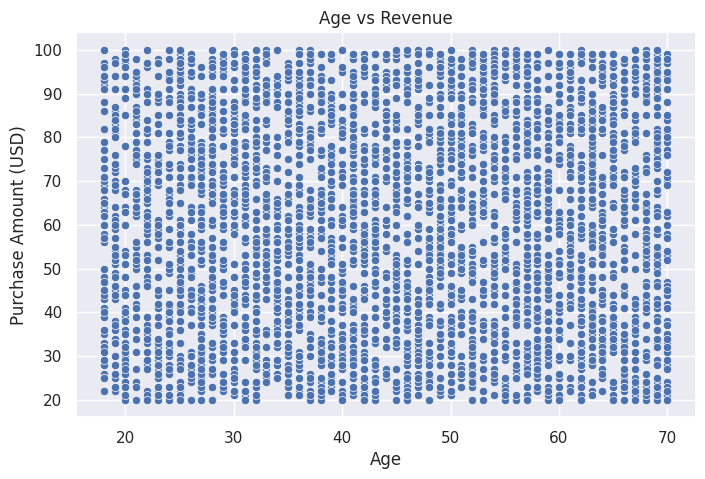

In [21]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='Age', y='Purchase Amount (USD)', data=df)
plt.title("Age vs Revenue")
plt.show()

### Correlation Matrix

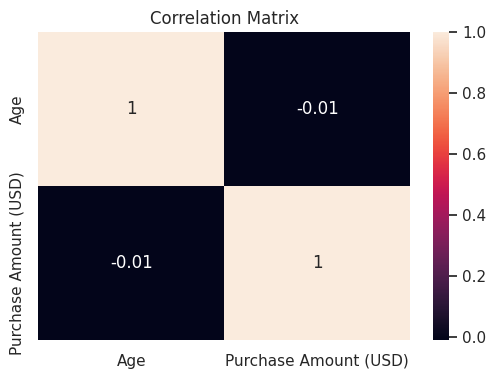

In [22]:
plt.figure(figsize=(6,4))
sns.heatmap(df[['Age', 'Purchase Amount (USD)']].corr(), annot=True)
plt.title("Correlation Matrix")
plt.show()

- Correlation close to 1 = strong positive relationship
- Close to 0 = weak relationship

## Time-Based Analysis
### Monthly Revenue Trend

In [ ]:
df['Month'] = df['Date'].dt.to_period('M')

monthly_revenue = df.groupby('Month')['Amount'].sum()

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.ylabel("Revenue")
plt.show()

My dataset don't have date